<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторная работа №8**

Тема: Web-приложение для демонстрации моделей машинного обучения.
Цель: разработать простое web-приложение, позволяющее обучать модели машинного обучения, задавать гиперпараметры и отображать результаты работы моделей.

В работе используется датасет agriculture.csv, который применялся в предыдущих лабораторных работах.
Решается задача классификации: предсказание признака Категория (низкий, средний, высокий).

В приложении реализовано:

загрузка и предобработка данных;
выбор модели классификации;
настройка гиперпараметров;
обучение модели;
вывод метрик качества;
построение матрицы ошибок;
визуализация важности признаков для дерева решений и случайного леса.


In [ ]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.4 MB/s eta 0:00:00


In [ ]:
import os

if os.path.exists('synthetic_coffee_health_10000.csv'):
    print('Файл synthetic_coffee_health_10000.csv')
else:
    print('Файл не найден. Загрузите его в рабочую область Colab.')

Файл не найден. Загрузите его в рабочую область Colab.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_coffee_health_10000.csv to synthetic_coffee_health_10000.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

st.set_page_config(page_title="ЛР №8: ML Web App", layout="wide")

st.title("Лабораторная работа №8")
st.subheader("Web-приложение для демонстрации моделей машинного обучения")

st.markdown("""
В приложении решается задача классификации для датасета **synthetic_coffee_health_10000.csv**.
Целевая переменная — **Health_Issues** (`No`, `Mild`, `Moderate`, `Severe`).
""")

@st.cache_data
def load_data(path):
    try:
        df = pd.read_csv(path, sep=',', encoding='cp1251')
    except:
        df = pd.read_csv(path, sep=',', encoding='utf-8')
    return df

# Если файл на Google Drive, раскомментируйте следующие строки:
#from google.colab import drive
#drive.mount('/content/drive')
#file_path = '/content/drive/MyDrive/synthetic_coffee_health_10000.csv'
# иначе укажите имя файла в текущей папке:
file_path = 'synthetic_coffee_health_10000.csv'

try:
    df = load_data(file_path)
except FileNotFoundError:
    st.error(f"Файл {file_path} не найден. Загрузите файл в рабочую область Colab или на Google Drive.")
    st.stop()

st.sidebar.header("Настройки модели")

model_name = st.sidebar.selectbox(
    "Выберите модель",
    ["Логистическая регрессия", "Дерево решений", "Случайный лес"]
)

test_size = st.sidebar.slider(
    "Доля тестовой выборки",
    min_value=0.1,
    max_value=0.4,
    value=0.2,
    step=0.05
)

random_state = st.sidebar.number_input(
    "random_state",
    min_value=0,
    max_value=1000,
    value=42,
    step=1
)

st.sidebar.markdown("---")

if model_name == "Логистическая регрессия":
    C = st.sidebar.slider("C", min_value=0.1, max_value=5.0, value=1.0, step=0.1)
    max_iter = st.sidebar.slider("max_iter", min_value=500, max_value=3000, value=2000, step=50)

elif model_name == "Дерево решений":
    max_depth = st.sidebar.slider("max_depth", min_value=2, max_value=15, value=5, step=1)
    min_samples_leaf = st.sidebar.slider("min_samples_leaf", min_value=1, max_value=10, value=1, step=1)

else:
    n_estimators = st.sidebar.slider("n_estimators", min_value=50, max_value=500, value=200, step=50)
    max_depth_rf = st.sidebar.slider("max_depth", min_value=2, max_value=20, value=8, step=1)
    min_samples_leaf_rf = st.sidebar.slider("min_samples_leaf", min_value=1, max_value=10, value=2, step=1)

st.header("1. Исходные данные")

col1, col2 = st.columns(2)

with col1:
    st.write("Первые строки датасета:")
    st.dataframe(df.head())

with col2:
    st.write("Количество пропусков:")
    st.dataframe(df.isna().sum().to_frame("Количество пропусков"))

st.write("Размер датасета:", df.shape)

st.header("2. Подготовка данных")

target_map = {'No': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
reverse_target_map = {v: k for k, v in target_map.items()}

df['Health_Issues_ord'] = df['Health_Issues'].map(target_map)

X = df.drop(columns=['Health_Issues', 'Health_Issues_ord'])
y = df['Health_Issues_ord']

numeric_features = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']
categorical_features = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation','Smoking', 'Alcohol_Consumption']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

st.write("Размер обучающей выборки:", X_train.shape)
st.write("Размер тестовой выборки:", X_test.shape)

st.write("Распределение классов:")
st.dataframe(y.value_counts().rename(index=reverse_target_map).to_frame("Количество"))

st.header("3. Обучение модели")

if model_name == "Логистическая регрессия":
    model = LogisticRegression(C=C, max_iter=max_iter, random_state=random_state, multi_class='multinomial')

elif model_name == "Дерево решений":
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )

else:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth_rf,
        min_samples_leaf=min_samples_leaf_rf,
        random_state=random_state,
        n_jobs=-1
    )

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

metric_col1, metric_col2 = st.columns(2)

with metric_col1:
    st.metric("Accuracy", round(accuracy, 4))

with metric_col2:
    st.metric("F1-macro", round(f1_macro, 4))

st.header("4. Отчёт классификации")

report = classification_report(
    y_test,
    y_pred,
    target_names=['No', 'Mild', 'Moderate', 'Severe'],
    output_dict=True,
    zero_division=0
)

st.dataframe(pd.DataFrame(report).transpose())

st.header("5. Матрица ошибок")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No', 'Mild', 'Moderate', 'Severe'],
    ax=ax,
    colorbar=False
)
ax.set_title(f"Матрица ошибок: {model_name}")
st.pyplot(fig)

st.header("6. Важность признаков")

if model_name in ["Дерево решений", "Случайный лес"]:
    fitted_preprocessor = pipeline.named_steps['preprocessor']
    fitted_model = pipeline.named_steps['model']

    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': importances
    }).sort_values(by='Важность', ascending=False)

    st.write("Топ-15 наиболее важных признаков:")
    st.dataframe(feature_importance_df.head(15))

    top_features = feature_importance_df.head(15)

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.barh(top_features['Признак'][::-1], top_features['Важность'][::-1])
    ax2.set_title("Важность признаков")
    ax2.set_xlabel("Важность")
    ax2.set_ylabel("Признак")
    st.pyplot(fig2)

else:
    st.info("Для логистической регрессии в данном приложении график важности признаков не строится.")

st.header("7. Вывод")

st.markdown(f"""
В ходе работы была обучена модель **{model_name}** для решения задачи классификации по датасету `synthetic_coffee_health_10000.csv`.
Перед обучением была выполнена предобработка данных: заполнение пропусков, кодирование категориальных признаков и масштабирование числовых признаков.
Качество модели оценивалось с помощью метрик **Accuracy** и **F1-macro**.

Полученные значения:
- Accuracy = **{accuracy:.4f}**;
- F1-macro = **{f1_macro:.4f}**.

Модель позволяет классифицировать объекты по категориям `No`, `Mild`, `Moderate`, `Severe` а интерактивные настройки в боковой панели позволяют изменять гиперпараметры и сравнивать результаты.
""")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('Файл app.py успешно создан.')

Файл app.py успешно создан.


In [ ]:
# Установка (уже должна быть)
!pip install streamlit -q

# Запуск в фоне
!streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &

# Подождать 5 секунд
import time
time.sleep(5)

# Скачать и запустить cloudflared
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-05-24T08:01:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-24T08:01:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-24T08:01:08Z INF +--------------------------------------------------------------------------------------------+
2026-05-24T08:01:08Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-24T08:01:08Z INF |  https://pixels-deals-holdings-kind.trycloudflare.com 

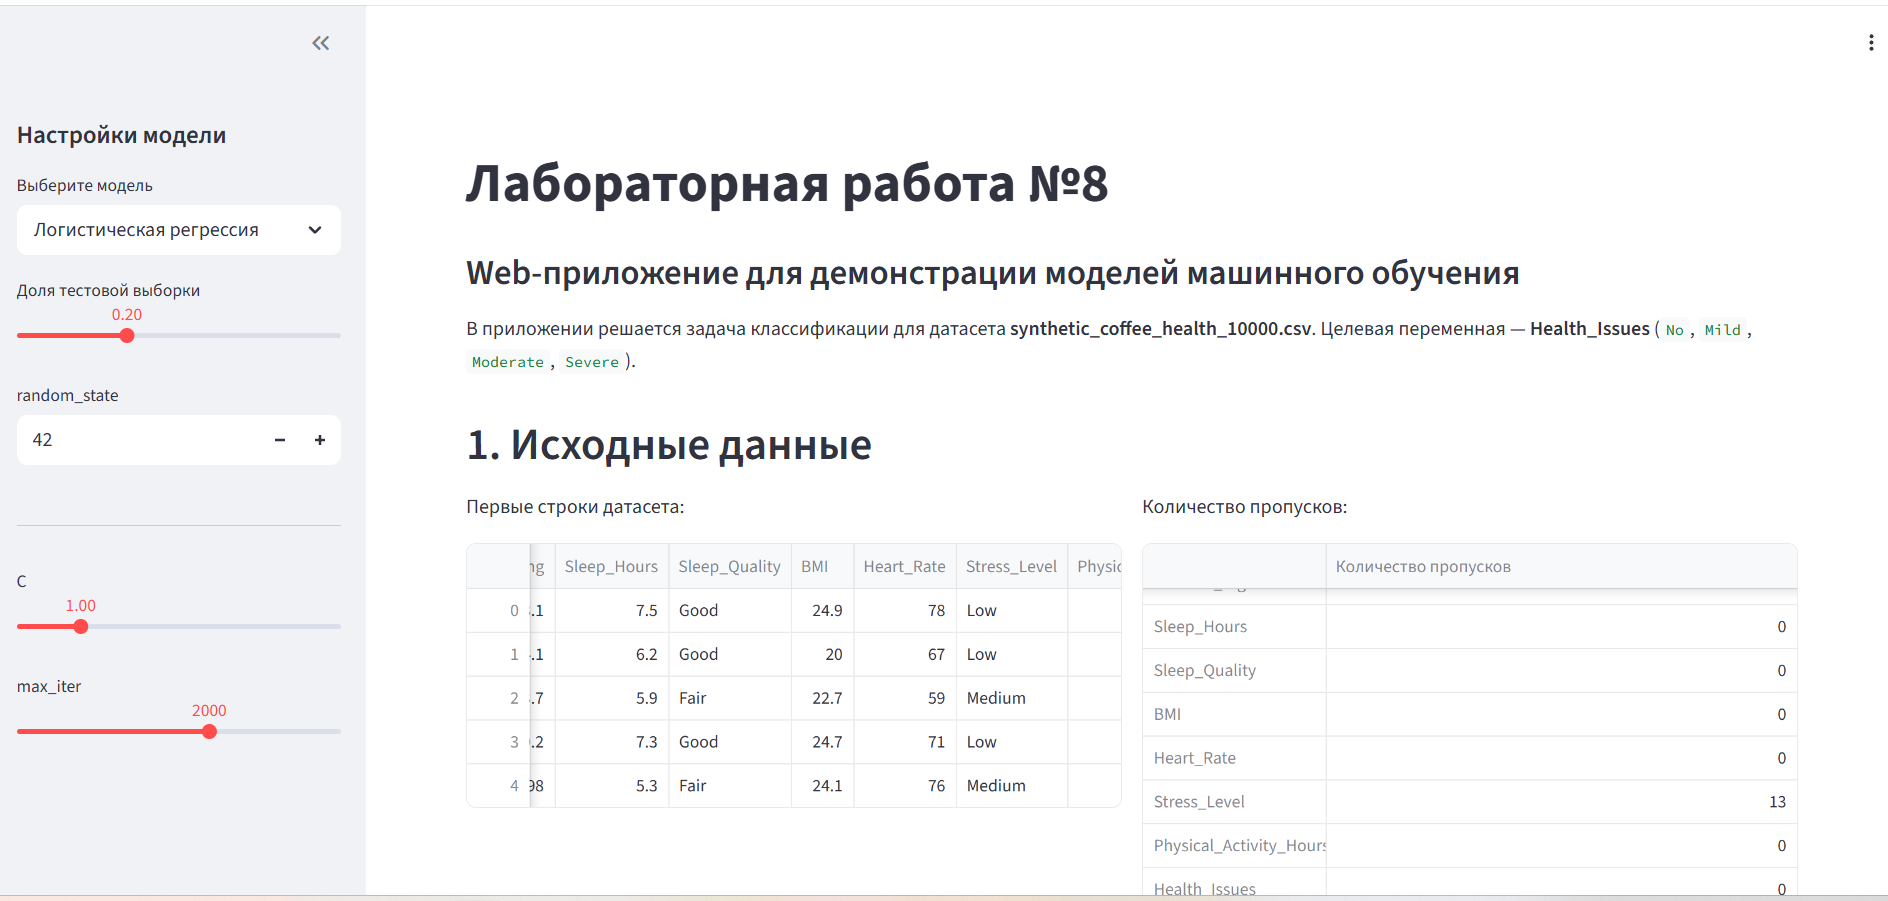

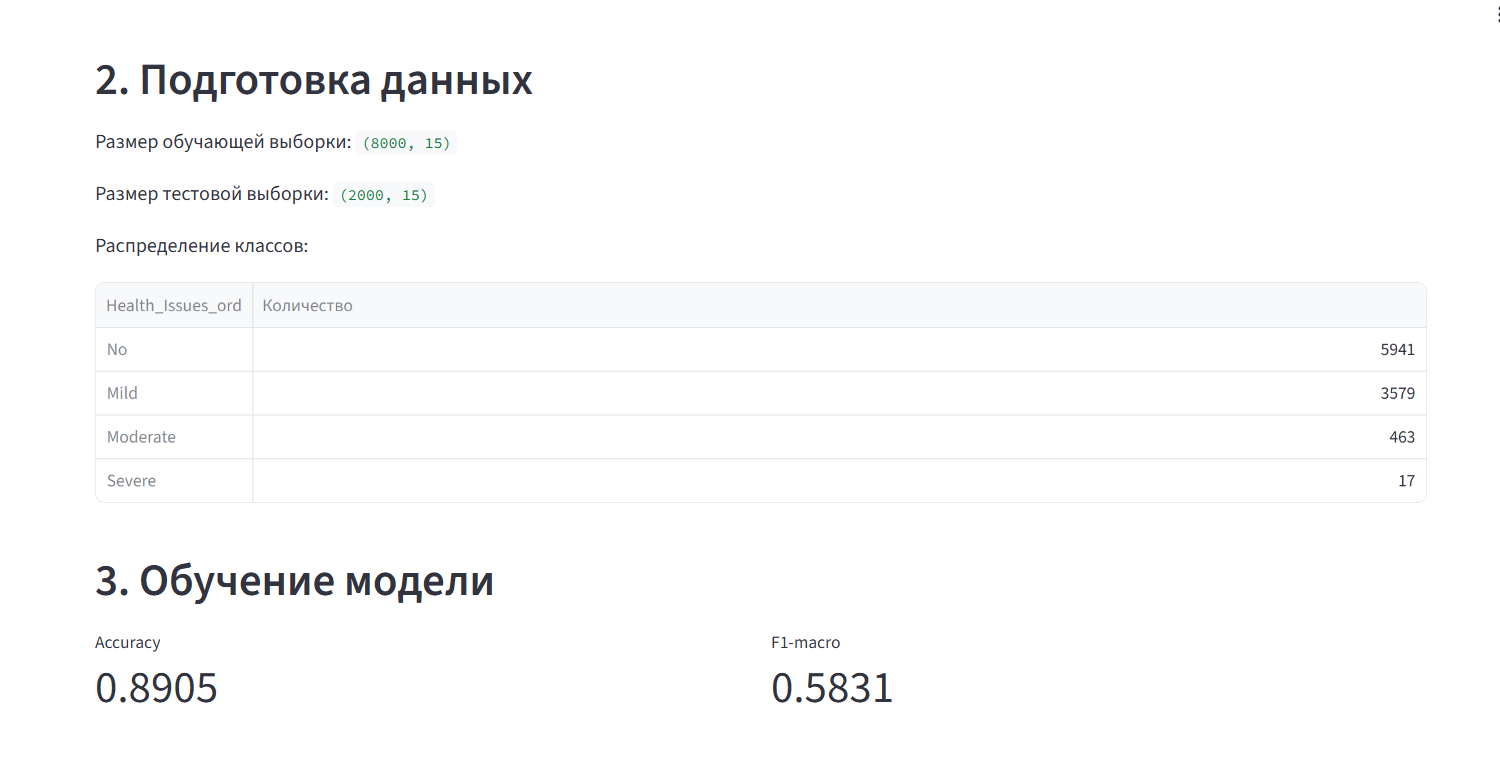

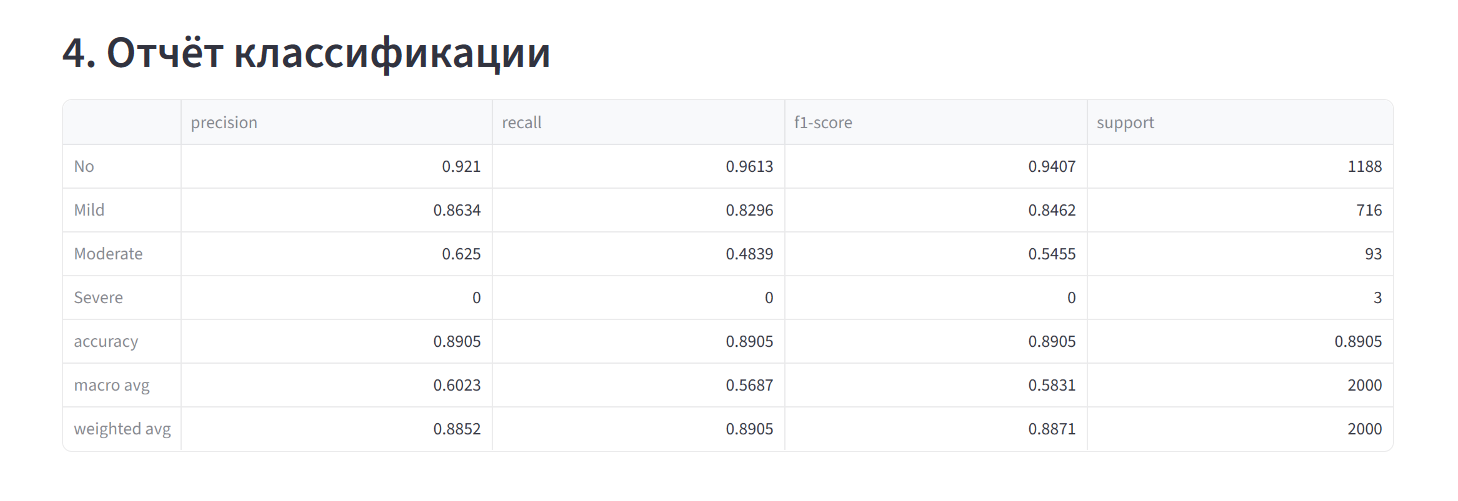

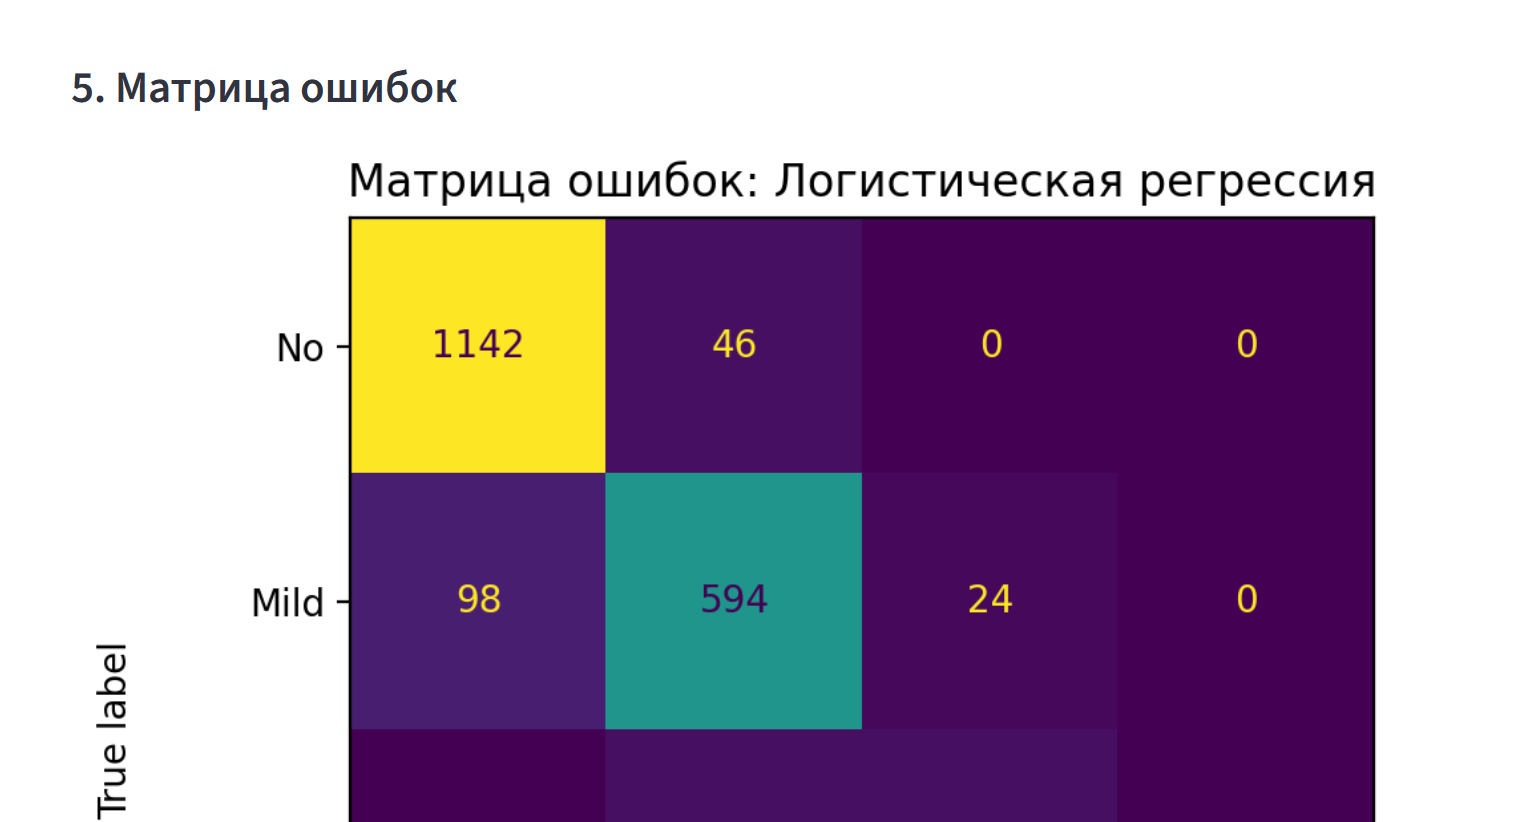

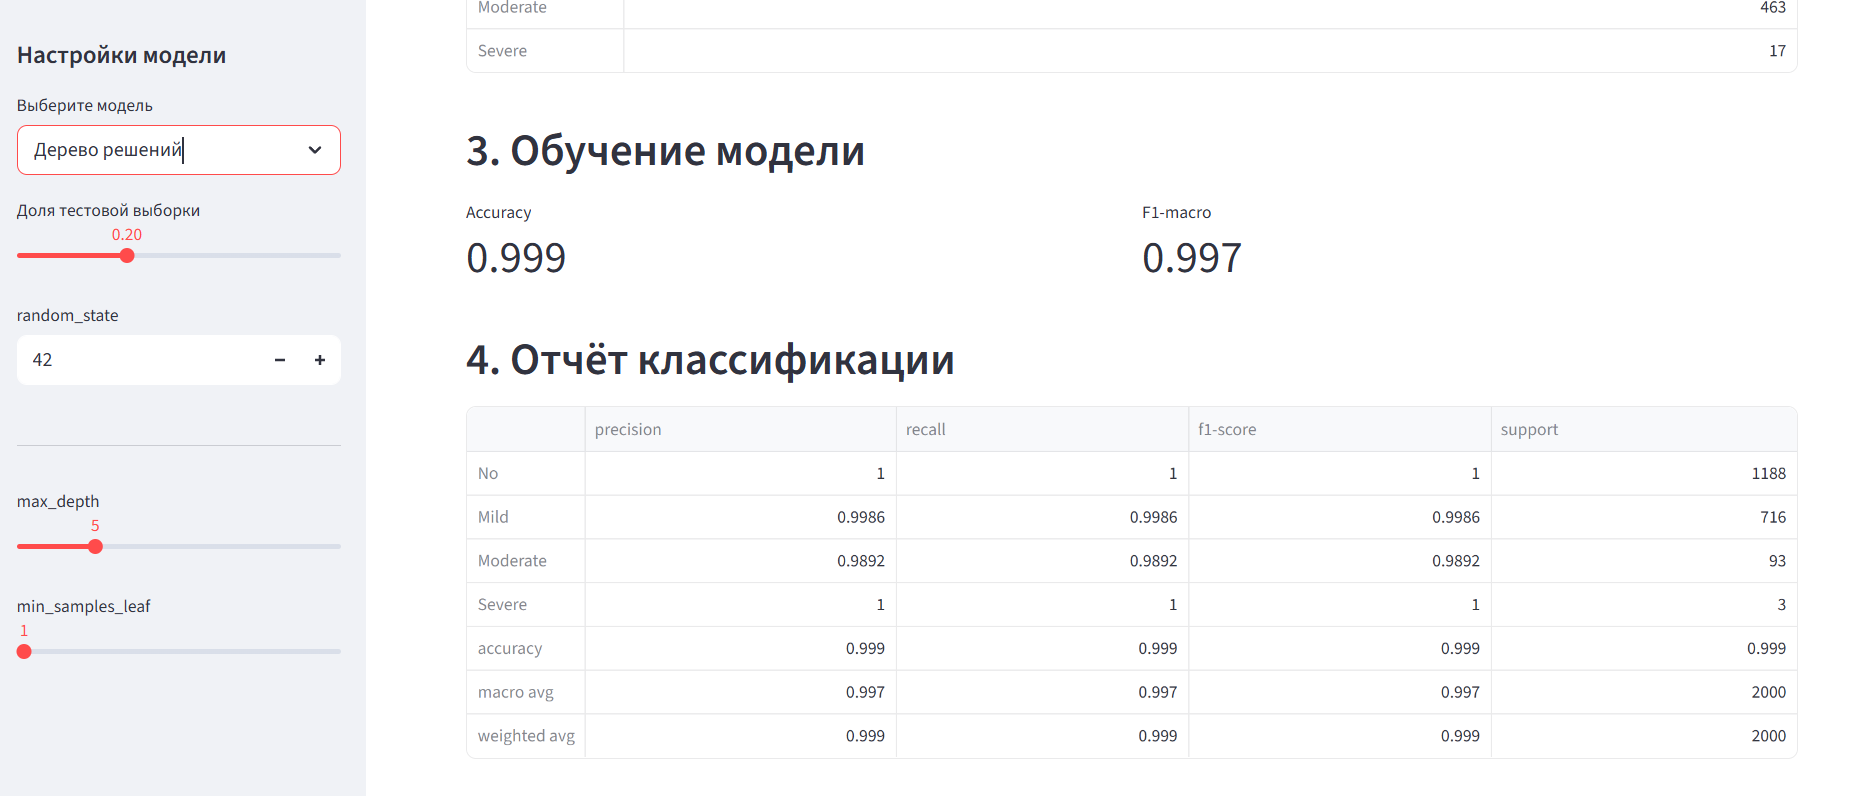